In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np

In [2]:
dataset = baseClasses.Data()

In [6]:
apa = systemClasses.System(dataset=dataset, name="APA")

ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERROR: Board (11) not found in equalization (FIRST_POFF_39644_39619_39614_40200_39607_39669)
ERROR: Board (11) not found
ERRO

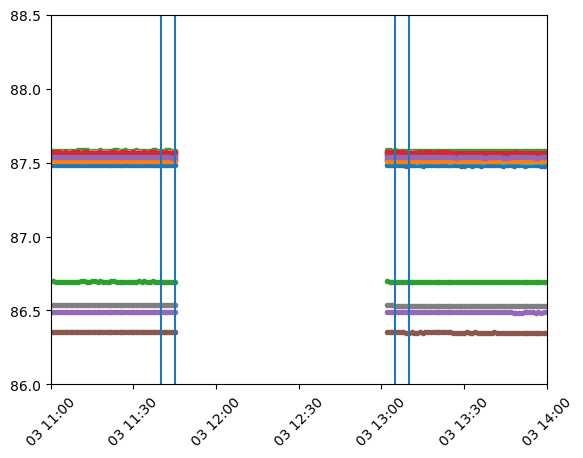

In [7]:
for id, sensor in apa.sensors.items():
    # if "F" not in sensor.name:
    #     continue
    sensor.muxEqualization()
    plt.plot(sensor.data, ".", label=sensor.name)
    end_temp = sensor.data.loc[(sensor.data.index > datetime.datetime(2024, 12, 3, 11, 40, 0)) & (sensor.data.index < datetime.datetime(2024, 12, 3, 11, 45, 0))].mean()
    ini_temp = sensor.data.loc[(sensor.data.index > datetime.datetime(2024, 12, 3, 13, 5, 0)) & (sensor.data.index < datetime.datetime(2024, 12, 3, 13, 10, 0))].mean()
    print(sensor.name, end_temp - ini_temp)
plt.xlim(datetime.datetime(2024, 12, 3, 11, 0, 0), datetime.datetime(2024, 12, 3, 14, 0, 0))
plt.ylim(86.0, 88.5)
plt.xticks(rotation=45);
plt.axvline(datetime.datetime(2024, 12, 3, 11, 40, 0))
plt.axvline(datetime.datetime(2024, 12, 3, 11, 45, 0))
plt.axvline(datetime.datetime(2024, 12, 3, 13, 5, 0))
plt.axvline(datetime.datetime(2024, 12, 3, 13, 10, 0))
# plt.legend(ncol=1)

TGRAD1 -0.0034113824913077906
TGRAD2 -0.008413255535614894


KeyboardInterrupt: 

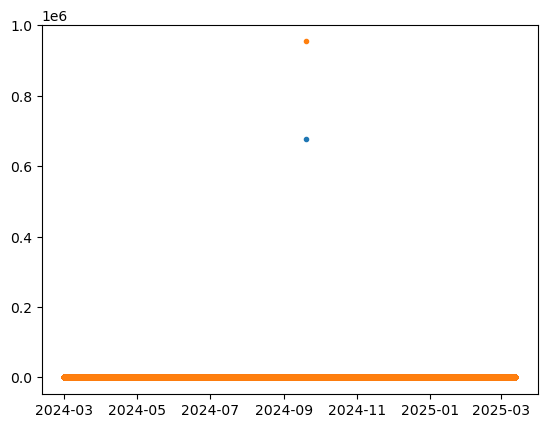

In [5]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
b1b2, b2b1 = [], []
for id, sensor in tgrad.sensors.items():
    # if "F" not in sensor.name:
    #     continue
    sensor.muxCorrection()
    plt.plot(sensor.data, ".", label=sensor.name)
    end_temp = sensor.data.loc[(sensor.data.index > datetime.datetime(2024, 9, 18, 10, 30, 0)) & (sensor.data.index < datetime.datetime(2024, 9, 18, 10, 35, 0))].mean()
    ini_temp = sensor.data.loc[(sensor.data.index > datetime.datetime(2024, 9, 18, 10, 55, 0)) & (sensor.data.index < datetime.datetime(2024, 9, 18, 11, 0, 0))].mean()
    print(sensor.name, end_temp - ini_temp)
    if (end_temp - ini_temp) < 0:
        b1b2.append(end_temp - ini_temp)
    elif (end_temp - ini_temp) > 0:
        b2b1.append(end_temp - ini_temp)
plt.xlim(datetime.datetime(2024, 9, 18, 10, 0, 0), datetime.datetime(2024, 9, 18, 11, 0, 0))
plt.ylim(87.5, 88.0)
plt.xticks(rotation=45);
# plt.axvline(datetime.datetime(2024, 12, 3, 11, 40, 0))
# plt.axvline(datetime.datetime(2024, 12, 3, 11, 45, 0))
# plt.axvline(datetime.datetime(2024, 12, 3, 13, 5, 0))
# plt.axvline(datetime.datetime(2024, 12, 3, 13, 10, 0))
# plt.legend(ncol=1)

(array([2., 2., 0., 2., 3., 4., 4., 3., 2., 2.]),
 array([0.00212554, 0.0027601 , 0.00339465, 0.00402921, 0.00466376,
        0.00529832, 0.00593287, 0.00656743, 0.00720198, 0.00783654,
        0.00847109]),
 <BarContainer object of 10 artists>)

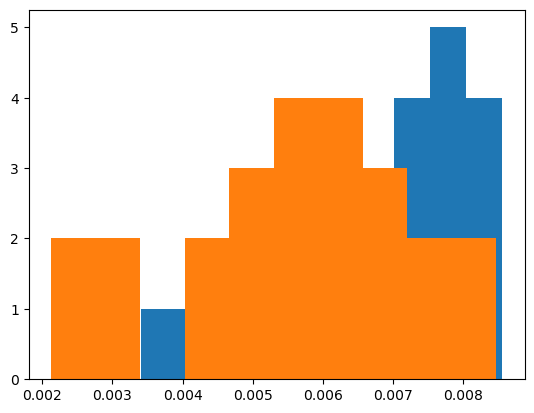

In [11]:
plt.hist(abs(np.array(b1b2)), bins=10)
plt.hist(b2b1, bins=10)

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9003) coordinates not found


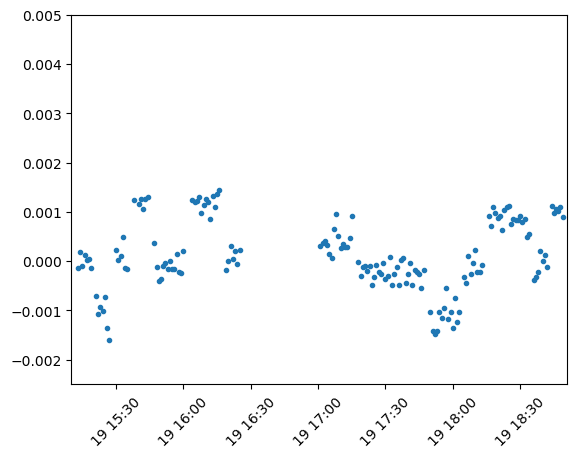

In [11]:
for id in [9003]:
    ref_resistor = sensorClasses.Sensor(dataset=dataset, id=9001)
    resistor = sensorClasses.Sensor(dataset=dataset, id=id)
    plt.plot((resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.7)] - ref_resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.75)]) - (resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.7)] - ref_resistor.data.loc[(resistor.data>76.3)&(resistor.data<76.75)])[0:7].mean(), ".")
    plt.xticks(rotation=45);
    plt.ylim(-0.0025, 0.005)
    plt.xlim(datetime.datetime(2024, 9, 19, 15, 10, 0), datetime.datetime(2024, 9, 19, 18, 51, 0))

ERROR: SensorID (9001) coordinates not found
ERROR: SensorID (9008) coordinates not found
ERROR: SensorID (9009) coordinates not found
ERROR: SensorID (9010) coordinates not found


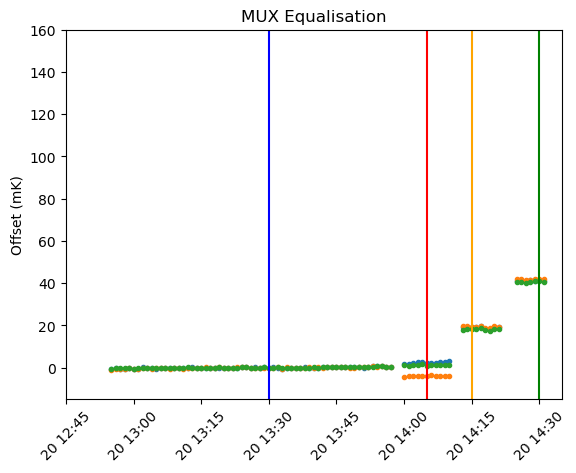

In [ ]:
ref_resistor = sensorClasses.Sensor(dataset=dataset, id=9001).muxEqualization()
for id in [9008, 9009, 9010]:
    resistor = sensorClasses.Sensor(dataset=dataset, id=id).muxEqualization()
    offset = 1e3*(resistor.data - ref_resistor.data)
    offset_b1 = offset - offset.loc[(offset.index > datetime.datetime(2024, 9, 20, 13, 0, 0)) & (offset.index < datetime.datetime(2024, 9, 20, 13, 55, 0))].mean()
    plt.plot(offset_b1, ".", label=f"HP Resistors: 9001-{id}")

plt.xticks(rotation=45);
plt.ylim(-15, 160)
plt.xlim(datetime.datetime(2024, 9, 20, 12, 45, 0), datetime.datetime(2024, 9, 20, 14, 35, 0))
plt.title("MUX Equalisation")
plt.ylabel("Offset (mK)")
plt.axvline(datetime.datetime(2024, 9, 20, 13, 30, 0), label="Board 1", color="blue")
plt.axvline(datetime.datetime(2024, 9, 20, 14, 5, 0), label="Board 2", color="red")
plt.axvline(datetime.datetime(2024, 9, 20, 14, 15, 0), label="Board 3", color="orange")
plt.axvline(datetime.datetime(2024, 9, 20, 14, 30, 0), label="Board 4", color="green")
# plt.legend()